# MAT353 Projesi — Normal Denklem vs Gradient Descent + Gradient Checking
Bu notebook tek başına çalışır; tüm kod hücreler içindedir. Figürler `outputs/figures/` altına kaydedilir.

In [91]:
# Gerekli kütüphaneler (Colab vb. temiz ortam için)
%pip install --quiet numpy pandas matplotlib scikit-learn seaborn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [92]:
import os, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

CWD = Path.cwd()
ROOT = CWD.parent if CWD.name == "notebooks" else CWD
OUTPUT_DIR = ROOT / "outputs" / "figures"
TABLE_DIR = ROOT / "outputs" / "tables"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = str(OUTPUT_DIR)
TABLE_DIR = str(TABLE_DIR)

sns.set_theme(style="whitegrid")


## Yardımcı Fonksiyonlar

In [93]:
# Veri üretimi (bias sütunu eklenmiş) ve ön işlem

def make_synthetic_linear(n=2000, d=20, p=6, noise_std=0.5, seed=42):
    rng = np.random.default_rng(seed)
    X_feat = rng.normal(size=(n, d))
    if d >= 2:
        x1 = X_feat[:, 0].copy()
        xi = rng.normal(size=n)
        X_feat[:, 1] = x1 + (10.0 ** (-p)) * xi  # kolinear özellik
    ones = np.ones((n, 1))
    X = np.hstack([ones, X_feat])  # bias sütunu
    theta_true = rng.normal(size=d + 1)
    noise = rng.normal(scale=noise_std, size=n)
    y = X @ theta_true + noise
    return X, y, theta_true


def train_val_split(X, y, val_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(X.shape[0])
    rng.shuffle(idx)
    cut = int(len(idx) * (1 - val_ratio))
    tr, val = idx[:cut], idx[cut:]
    return X[tr], X[val], y[tr], y[val]


def standardize(X_tr, X_val):
    # Bias sütunu (ilk sütun) korunur, yalnızca özellikler ölçeklenir
    Xtr_b, Xtr_f = X_tr[:, :1], X_tr[:, 1:]
    Xval_b, Xval_f = X_val[:, :1], X_val[:, 1:]
    mean = Xtr_f.mean(axis=0, keepdims=True)
    std = Xtr_f.std(axis=0, keepdims=True)
    std[std == 0] = 1.0
    Xtr_scaled = np.hstack([Xtr_b, (Xtr_f - mean) / std])
    Xval_scaled = np.hstack([Xval_b, (Xval_f - mean) / std])
    return Xtr_scaled, Xval_scaled, mean, std


def unscale_theta(theta_scaled, mean, std):
    # theta_scaled: [bias, scaled_features]
    bias = theta_scaled[0]
    w = theta_scaled[1:]
    w_raw = w / std.ravel()
    bias_raw = bias - np.sum((mean.ravel() / std.ravel()) * w)
    return np.concatenate([[bias_raw], w_raw])

# Metrikler

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def cond_xtx(X):
    return float(np.linalg.cond(X.T @ X))


def cond_x(X):
    return float(np.linalg.cond(X))

# Çözücüler (try/except ile)

def predict(X, theta):
    return X @ theta


def normal_eq_inverse(X, y):
    try:
        xtx, xty = X.T @ X, X.T @ y
        return np.linalg.inv(xtx) @ xty
    except Exception as e:
        print("inverse failed:", e)
        return np.full(X.shape[1], np.nan)


def normal_eq_solve(X, y, lam=0.0):
    try:
        xtx, xty = X.T @ X, X.T @ y
        if lam > 0:
            xtx = xtx + lam * np.eye(xtx.shape[0])
        return np.linalg.solve(xtx, xty)
    except Exception as e:
        print("solve failed:", e)
        return np.full(X.shape[1], np.nan)


def least_squares_qr(X, y):
    try:
        theta, *_ = np.linalg.lstsq(X, y, rcond=None)
        return theta
    except Exception as e:
        print("lstsq failed:", e)
        return np.full(X.shape[1], np.nan)


def least_squares_explicit_qr(X, y):
    try:
        Q, R = np.linalg.qr(X)
        qty = Q.T @ y
        return np.linalg.solve(R, qty)
    except Exception as e:
        print("explicit QR failed:", e)
        return np.full(X.shape[1], np.nan)


def gradient_descent(X, y, alpha=1e-2, max_iter=5000, tol=1e-6, log_every=10, theta0=None):
    n, d = X.shape
    theta = np.zeros(d) if theta0 is None else theta0.copy()
    history = {"iter": [], "loss": [], "grad_norm": [], "time": []}

    def loss(th):
        return float(0.5 / n * np.sum((X @ th - y) ** 2))

    start = time.time()
    prev_loss = loss(theta)
    for k in range(max_iter):
        grad = (1.0 / n) * (X.T @ (X @ theta - y))
        theta -= alpha * grad
        if k % log_every == 0 or k == max_iter - 1:
            curr = loss(theta)
            gnorm = float(np.linalg.norm(grad))
            history["iter"].append(k)
            history["loss"].append(curr)
            history["grad_norm"].append(gnorm)
            history["time"].append(time.time() - start)
            if abs(curr - prev_loss) / (prev_loss + 1e-12) < tol:
                break
            prev_loss = curr
    return theta, history

# Gradient checking (dtype uyumlu)

def loss_mse(theta, X, y):
    n = X.shape[0]
    return float((0.5 / n) * np.sum((X @ theta - y) ** 2))


def grad_mse_analytic(theta, X, y):
    n = X.shape[0]
    return (1.0 / n) * (X.T @ (X @ theta - y))


def grad_numeric_central(J, theta, eps):
    dtype = theta.dtype
    grad = np.zeros_like(theta)
    eps = dtype.type(eps)
    two = dtype.type(2.0)
    one = dtype.type(1.0)
    for i in range(theta.size):
        e = np.zeros_like(theta)
        e[i] = one
        grad[i] = (J(theta + eps * e) - J(theta - eps * e)) / (two * eps)
    return grad


def epsilon_sweep(theta, X, y, eps_list, dtype=np.float64):
    Xc = X.astype(dtype)
    yc = y.astype(dtype)
    theta_c = theta.astype(dtype)
    J = lambda t: loss_mse(t, Xc, yc)
    g_true = grad_mse_analytic(theta_c, Xc, yc)
    rows = []
    for eps in eps_list:
        g_num = grad_numeric_central(J, theta_c, eps)
        diff = (g_true - g_num).astype(np.float64)
        denom = max(np.linalg.norm(g_true.astype(np.float64)), np.linalg.norm(g_num.astype(np.float64)), 1e-12)
        relerr = float(np.linalg.norm(diff) / denom)
        rows.append({"eps": eps, "relerr": relerr, "dtype": str(dtype)})
    return rows


def alpha_sweep_gd(alpha_list, n=2000, d=20, p=6, noise_std=0.5, seed=42, max_iter=2000, tol=1e-6):
    rows = []
    X, y, _ = make_synthetic_linear(n=n, d=d, p=p, noise_std=noise_std, seed=seed)
    X_tr, X_val, y_tr, y_val = train_val_split(X, y, val_ratio=0.2, seed=seed)
    X_tr_std, X_val_std, mean, std = standardize(X_tr, X_val)
    for alpha in alpha_list:
        theta_gd, hist = gradient_descent(X_tr_std, y_tr, alpha=alpha, max_iter=max_iter, tol=tol, log_every=20)
        y_val_pred = predict(X_val_std, theta_gd)
        rmse_val = rmse(y_val, y_val_pred)
        rows.append({
            "alpha": float(alpha),
            "rmse_val": float(rmse_val),
            "gd_iters": hist["iter"][-1] if hist["iter"] else 0,
            "diverged": not np.isfinite(rmse_val),
        })
    return pd.DataFrame(rows)


def alpha_sweep_gd_from_data(X_tr, X_val, y_tr, y_val, alpha_list, max_iter=1000, tol=1e-6, log_every=50):
    rows = []
    for alpha in alpha_list:
        theta_gd, hist = gradient_descent(X_tr, y_tr, alpha=alpha, max_iter=max_iter, tol=tol, log_every=log_every)
        y_val_pred = predict(X_val, theta_gd)
        rmse_val = rmse(y_val, y_val_pred)
        rows.append({
            "alpha": float(alpha),
            "rmse_val": float(rmse_val),
            "gd_iters": hist["iter"][-1] if hist["iter"] else 0,
            "diverged": not np.isfinite(rmse_val),
        })
    return pd.DataFrame(rows)

# Deneyler

def run_conditioning_experiment(p_values, n=2000, d=20, noise_std=0.5, alpha=1e-2, max_iter=2000, tol=1e-6, seed=42, use_qr=True, standardize_for_gd=True):
    rows = []
    for p in p_values:
        X, y, theta_true = make_synthetic_linear(n=n, d=d, p=p, noise_std=noise_std, seed=seed)
        X_tr, X_val, y_tr, y_val = train_val_split(X, y, val_ratio=0.2, seed=seed)

        X_tr_std, X_val_std, mean_std, std_std = standardize(X_tr, X_val)
        cond_xtx_std = cond_xtx(X_tr_std)

        theta_inv = normal_eq_inverse(X_tr, y_tr)
        theta_solve = normal_eq_solve(X_tr, y_tr)
        theta_qr = least_squares_qr(X_tr, y_tr) if use_qr else None
        theta_qr_exp = least_squares_explicit_qr(X_tr, y_tr) if use_qr else None

        def row_for(theta, label):
            yhat_tr = predict(X_tr, theta)
            yhat_val = predict(X_val, theta)
            return {
                "p": p,
                "method": label,
                "cond_xtx": cond_xtx(X_tr),
                "cond_xtx_std": cond_xtx_std,
                "cond_x": cond_x(X_tr),
                "rmse_train": rmse(y_tr, yhat_tr),
                "rmse_val": rmse(y_val, yhat_val),
                "theta_err": float(np.linalg.norm(theta - theta_true)) if np.isfinite(theta).all() else np.nan,
            }

        rows.append(row_for(theta_inv, "inverse"))
        rows.append(row_for(theta_solve, "solve"))
        if theta_qr is not None:
            rows.append(row_for(theta_qr, "qr_lstsq"))
        if theta_qr_exp is not None:
            rows.append(row_for(theta_qr_exp, "qr_explicit"))

        X_gd_tr, X_gd_val = (X_tr_std, X_val_std) if standardize_for_gd else (X_tr, X_val)
        mean = std = None
        if standardize_for_gd:
            mean, std = mean_std, std_std
        theta_gd, hist = gradient_descent(X_gd_tr, y_tr, alpha=alpha, max_iter=max_iter, tol=tol)
        # theta_err için geri ölçekleme
        theta_gd_raw = unscale_theta(theta_gd, mean, std) if mean is not None else theta_gd
        rows.append({
            "p": p,
            "method": "gd",
            "cond_xtx": cond_xtx(X_tr),
            "cond_xtx_std": cond_xtx_std,
            "cond_x": cond_x(X_tr),
            "rmse_train": rmse(y_tr, predict(X_gd_tr, theta_gd)),
            "rmse_val": rmse(y_val, predict(X_gd_val, theta_gd)),
            "theta_err": float(np.linalg.norm(theta_gd_raw - theta_true)),
            "gd_iters": hist["iter"][-1] if hist["iter"] else 0,
        })
    return pd.DataFrame(rows)


def run_gradient_check_experiment(n=500, d=10, p=4, noise_std=0.5, eps_list=None, seed=123, include_float32=True):
    if eps_list is None:
        eps_list = [10.0 ** (-k) for k in range(1, 11)]
    X, y, _ = make_synthetic_linear(n=n, d=d, p=p, noise_std=noise_std, seed=seed)
    theta0 = np.random.default_rng(seed).normal(size=d + 1)
    rows = epsilon_sweep(theta0, X, y, eps_list, dtype=np.float64)
    if include_float32:
        rows += epsilon_sweep(theta0, X, y, eps_list, dtype=np.float32)
    return pd.DataFrame(rows)


def run_runtime_experiment(n_values, d_values, noise_std=0.5, seed=7, alpha=1e-2, max_iter=500, tol=1e-6):
    rows_n, rows_d = [], []
    for n in n_values:
        X, y, _ = make_synthetic_linear(n=n, d=20, p=3, noise_std=noise_std, seed=seed)
        t0 = time.time(); _ = normal_eq_solve(X, y); rows_n.append({"n": n, "runtime_s": time.time()-t0, "method": "solve"})
        t0 = time.time(); _, _ = gradient_descent(X, y, alpha=alpha, max_iter=max_iter, tol=tol); rows_n.append({"n": n, "runtime_s": time.time()-t0, "method": "gd"})
    for d in d_values:
        X, y, _ = make_synthetic_linear(n=2000, d=d, p=3, noise_std=noise_std, seed=seed)
        t0 = time.time(); _ = normal_eq_solve(X, y); rows_d.append({"d": d, "runtime_s": time.time()-t0, "method": "solve"})
        t0 = time.time(); _, _ = gradient_descent(X, y, alpha=alpha, max_iter=max_iter, tol=tol); rows_d.append({"d": d, "runtime_s": time.time()-t0, "method": "gd"})
    return pd.DataFrame(rows_n), pd.DataFrame(rows_d)

# Plot fonksiyonları

def plot_cond_vs_error(df, path=None):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [3, 2]})

    style_map = {
        "gd": {"marker": "o", "linestyle": "-", "alpha": 0.9, "color": "tab:blue", "zorder": 2, "markersize": 6},
        "qr_explicit": {"marker": "^", "linestyle": "--", "alpha": 0.95, "color": "tab:orange", "markerfacecolor": "none", "markeredgewidth": 1.6, "zorder": 4, "markersize": 7},
        "qr_lstsq": {"marker": "s", "linestyle": ":", "alpha": 0.95, "color": "tab:green", "markerfacecolor": "none", "markeredgewidth": 1.6, "zorder": 3, "markersize": 6},
        "solve": {"marker": "D", "linestyle": "-.", "alpha": 0.7, "color": "tab:red", "zorder": 1, "markersize": 6},
        "inverse": {"marker": "o", "linestyle": "-", "alpha": 0.9, "color": "tab:blue", "zorder": 2, "markersize": 6},
    }
    method_order = ["solve", "qr_lstsq", "qr_explicit", "gd"]

    df_noinv = df[df["method"] != "inverse"]
    for method in method_order:
        if method not in df_noinv["method"].unique():
            continue
        g = df_noinv[df_noinv["method"] == method].sort_values("cond_xtx")
        style = style_map.get(method, {})
        ax[0].plot(g["cond_xtx"], g["rmse_val"], linewidth=2, label=method, **style)

    ax[0].set_xscale("log")
    ax[0].set_xlabel("cond(X^T X)")
    ax[0].set_ylabel("RMSE (val)")
    ax[0].set_title("Stabil yöntemler")
    ax[0].grid(True, which="both", alpha=0.3)
    ax[0].legend(loc="best")

    y_vals = df_noinv["rmse_val"].to_numpy(dtype=float)
    if np.isfinite(y_vals).any():
        y_min = float(np.nanmin(y_vals))
        y_max = float(np.nanmax(y_vals))
        pad = (y_max - y_min) * 0.25 if y_max > y_min else max(abs(y_max) * 0.03, 0.02)
        ax[0].set_ylim(max(0.0, y_min - pad), y_max + pad)

    inv = df[df["method"] == "inverse"].sort_values("cond_xtx")
    if len(inv) > 0:
        style = style_map.get("inverse", {})
        ax[1].plot(inv["cond_xtx"], inv["rmse_val"], linewidth=2, label="inverse", **style)
        ax[1].set_xscale("log")
        ax[1].set_yscale("log")
        ax[1].set_xlabel("cond(X^T X)")
        ax[1].set_ylabel("RMSE (val)")
        ax[1].set_title("inverse (outlier)")
        ax[1].grid(True, which="both", alpha=0.3)
        ax[1].legend(loc="best")
    else:
        ax[1].axis("off")

    fig.suptitle("Koşullanma vs doğruluk", y=1.02)
    fig.tight_layout()

    if path:
        fig.savefig(path, bbox_inches="tight", dpi=150)
    return fig, ax

def plot_p_vs_cond(df, path=None):
    fig, ax = plt.subplots(figsize=(6,4))
    for method, group in df.groupby("method"):
        ax.plot(group["p"], group["cond_xtx"], marker="o", label=method)
    ax.set_yscale("log"); ax.set_xlabel("p (kolinear şiddeti)"); ax.set_ylabel("cond(X^T X)"); ax.set_title("p -> cond(X^T X)"); ax.legend(); ax.grid(True, which="both", alpha=0.3)
    if path: fig.savefig(path, bbox_inches="tight", dpi=150)
    return fig, ax


def plot_p_vs_rmse(df, path=None):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [3, 2]})

    style_map = {
        "gd": {"marker": "o", "linestyle": "-", "alpha": 0.9, "color": "tab:blue", "zorder": 2, "markersize": 6},
        "qr_explicit": {"marker": "^", "linestyle": "--", "alpha": 0.95, "color": "tab:orange", "markerfacecolor": "none", "markeredgewidth": 1.6, "zorder": 4, "markersize": 7},
        "qr_lstsq": {"marker": "s", "linestyle": ":", "alpha": 0.95, "color": "tab:green", "markerfacecolor": "none", "markeredgewidth": 1.6, "zorder": 3, "markersize": 6},
        "solve": {"marker": "D", "linestyle": "-.", "alpha": 0.7, "color": "tab:red", "zorder": 1, "markersize": 6},
        "inverse": {"marker": "o", "linestyle": "-", "alpha": 0.9, "color": "tab:blue", "zorder": 2, "markersize": 6},
    }
    method_order = ["solve", "qr_lstsq", "qr_explicit", "gd"]

    df_noinv = df[df["method"] != "inverse"]
    for method in method_order:
        if method not in df_noinv["method"].unique():
            continue
        g = df_noinv[df_noinv["method"] == method].sort_values("p")
        style = style_map.get(method, {})
        ax[0].plot(g["p"], g["rmse_val"], linewidth=2, label=method, **style)

    ax[0].set_xlabel("p (kolinear şiddeti)")
    ax[0].set_ylabel("RMSE (val)")
    ax[0].set_title("Stabil yöntemler")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend(loc="best")

    y_vals = df_noinv["rmse_val"].to_numpy(dtype=float)
    if np.isfinite(y_vals).any():
        y_min = float(np.nanmin(y_vals))
        y_max = float(np.nanmax(y_vals))
        pad = (y_max - y_min) * 0.35 if y_max > y_min else max(abs(y_max) * 0.03, 0.02)
        ax[0].set_ylim(max(0.0, y_min - pad), y_max + pad)

    inv = df[df["method"] == "inverse"].sort_values("p")
    if len(inv) > 0:
        style = style_map.get("inverse", {})
        ax[1].plot(inv["p"], inv["rmse_val"], linewidth=2, label="inverse", **style)
        ax[1].set_xlabel("p")
        ax[1].set_ylabel("RMSE (val)")
        ax[1].set_yscale("log")
        ax[1].set_title("inverse (outlier)")
        ax[1].grid(True, which="both", alpha=0.3)
        ax[1].legend(loc="best")
    else:
        ax[1].axis("off")

    fig.suptitle("p -> RMSE", y=1.02)
    fig.tight_layout()

    if path:
        fig.savefig(path, bbox_inches="tight", dpi=150)
    return fig, ax

def plot_gd_history(hist, path=None):
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    ax[0].plot(hist["iter"], hist["loss"]); ax[0].set_xlabel("Iterasyon"); ax[0].set_ylabel("Loss"); ax[0].set_title("GD Loss"); ax[0].grid(True, alpha=0.3)
    ax[1].plot(hist["iter"], hist["grad_norm"]); ax[1].set_xlabel("Iterasyon"); ax[1].set_ylabel("||grad||"); ax[1].set_title("GD grad norm"); ax[1].grid(True, alpha=0.3)
    if path: fig.savefig(path, bbox_inches="tight", dpi=150)
    return fig, ax


def plot_epsilon_sweep(df_eps, path=None):
    fig, ax = plt.subplots(figsize=(6,4))
    for dtype, g in df_eps.groupby("dtype"):
        ax.plot(g["eps"], g["relerr"], marker="o", label=dtype)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("epsilon"); ax.set_ylabel("relative error"); ax.set_title("Gradient checking: epsilon taraması"); ax.grid(True, which="both", alpha=0.3); ax.legend()
    if path: fig.savefig(path, bbox_inches="tight", dpi=150)
    return fig, ax


def plot_runtime(df, xcol, title, path=None):
    df2 = df.copy()
    df2["runtime_ms"] = df2["runtime_s"].astype(float) * 1000.0

    fig, ax = plt.subplots(figsize=(7, 4))
    for method, g in df2.groupby("method"):
        g = g.sort_values(xcol)
        ax.plot(g[xcol], g["runtime_ms"], marker="o", linewidth=2, label=method)

    ax.set_xlabel(xcol)
    ax.set_ylabel("Süre (ms)")
    ax.set_title(f"{title} (log)")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="best")

    fig.tight_layout()
    if path:
        fig.savefig(path, bbox_inches="tight", dpi=150)
    return fig, ax

# Basit testler

def run_tests():
    X, y, _ = make_synthetic_linear(n=200, d=5, p=2, seed=123)
    theta_s = normal_eq_solve(X, y)
    theta_q = least_squares_qr(X, y)
    assert np.allclose(theta_s, theta_q, atol=1e-6), "solve vs qr tutarsız"
    # Gradient check orta eps
    eps_list = [1e-3]
    df = run_gradient_check_experiment(n=200, d=5, p=2, eps_list=eps_list, seed=123, include_float32=False)
    assert df.relerr.iloc[0] < 1e-4, "gradient check relerr yüksek"
    print("Tests passed.")

# Kayıt yardımcıları
import json

def save_table(df, name):
    path = os.path.join(TABLE_DIR, f"{name}.csv")
    df.to_csv(path, index=False)
    print('Saved table ->', path)

def save_fig(fig, name, tight=True):
    if tight:
        fig.tight_layout()
    path = os.path.join(OUTPUT_DIR, f"{name}.png")
    fig.savefig(path, dpi=150)
    print('Saved figure ->', path)

def log_versions():
    versions = {
        'numpy': np.__version__,
        'pandas': pd.__version__,
        'matplotlib': plt.matplotlib.__version__,
        'seaborn': sns.__version__,
    }
    try:
        import sklearn
        versions['sklearn'] = sklearn.__version__
    except Exception:
        pass
    path = os.path.join(TABLE_DIR, 'versions.json')
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(versions, f, ensure_ascii=False, indent=2)
    print('Saved versions ->', path)

log_versions()

sns.set_context("talk", font_scale=0.85)

plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})


def annotate_bars(ax, bars, values=None, fmt="{:.4f}", fontsize=10, rotation=0, log_scale=False):
    if values is None:
        values = [b.get_height() for b in bars]

    finite_vals = [v for v in values if np.isfinite(v)]
    if not finite_vals:
        return

    y_min = float(np.min(finite_vals))
    y_max = float(np.max(finite_vals))

    if log_scale:
        for b, v in zip(bars, values):
            if not np.isfinite(v) or v <= 0:
                continue
            ax.text(
                b.get_x() + b.get_width() / 2,
                v * 1.18,
                fmt.format(v),
                ha="center",
                va="bottom",
                fontsize=fontsize,
                rotation=rotation,
            )
        return

    pad = (y_max - y_min) * 0.06 if y_max > y_min else max(abs(y_max) * 0.02, 0.01)
    for b, v in zip(bars, values):
        if not np.isfinite(v):
            continue
        ax.text(
            b.get_x() + b.get_width() / 2,
            v + pad,
            fmt.format(v),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            rotation=rotation,
        )


Saved versions -> /Users/semihbekdas/Documents/ders notlarim/Numeric/numerikproje/projesemih/outputs/tables/versions.json


## 1) Sentetik veri ve kapalı form çözümler

In [94]:
X, y, theta_true = make_synthetic_linear(n=2000, d=20, p=6, noise_std=0.5, seed=SEED)
X_tr, X_val, y_tr, y_val = train_val_split(X, y, val_ratio=0.2, seed=SEED)

theta_inv = normal_eq_inverse(X_tr, y_tr)
theta_solve = normal_eq_solve(X_tr, y_tr)
theta_qr = least_squares_qr(X_tr, y_tr)
theta_qr_exp = least_squares_explicit_qr(X_tr, y_tr)

print("RMSE (inverse)", rmse(y_val, predict(X_val, theta_inv)))
print("RMSE (solve)", rmse(y_val, predict(X_val, theta_solve)))
print("RMSE (QR-lstsq)", rmse(y_val, predict(X_val, theta_qr)))
print("RMSE (QR-explicit)", rmse(y_val, predict(X_val, theta_qr_exp)))

RMSE (inverse) 0.5002362487686293
RMSE (solve) 0.5002642027289416
RMSE (QR-lstsq) 0.5002657606072205
RMSE (QR-explicit) 0.5002657606074403


## 2) GD öğrenme oranı taraması (alpha sweep)


Saved table -> /Users/semihbekdas/Documents/ders notlarim/Numeric/numerikproje/projesemih/outputs/tables/alpha_sweep.csv
Selected GD_ALPHA: 0.003
Saved figure -> /Users/semihbekdas/Documents/ders notlarim/Numeric/numerikproje/projesemih/outputs/figures/alpha_sweep.png


,alpha,rmse_val,gd_iters,diverged
3,0.0030,0.499979,1999,False
4,0.0100,0.500021,940,False
5,0.0300,0.500028,340,False
6,0.1000,0.500032,120,False
2,0.0010,0.791020,1999,False
1,0.0003,2.415477,1999,False
0,0.0001,3.571510,1999,False


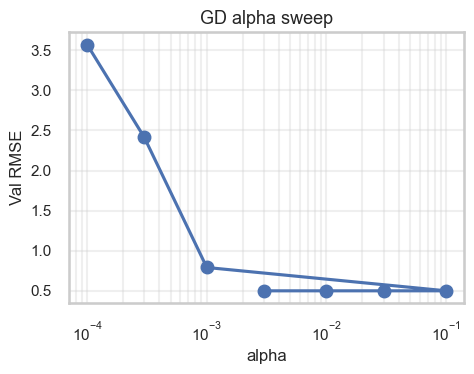

In [95]:
alpha_list = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]
df_alpha = alpha_sweep_gd(alpha_list=alpha_list, n=2000, d=20, p=6, noise_std=0.5, seed=SEED, max_iter=2000, tol=1e-6)
df_alpha = df_alpha.sort_values("rmse_val")
save_table(df_alpha, "alpha_sweep")

best_row = df_alpha[df_alpha["diverged"] == False].iloc[0]
GD_ALPHA = float(best_row["alpha"])
print("Selected GD_ALPHA:", GD_ALPHA)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(df_alpha["alpha"], df_alpha["rmse_val"], marker="o")
ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("Val RMSE")
ax.set_title("GD alpha sweep")
ax.grid(True, which="both", alpha=0.3)
save_fig(fig, "alpha_sweep")
df_alpha


## 3) Gradient Descent yakınsama

RMSE (GD) 0.49997880494165536


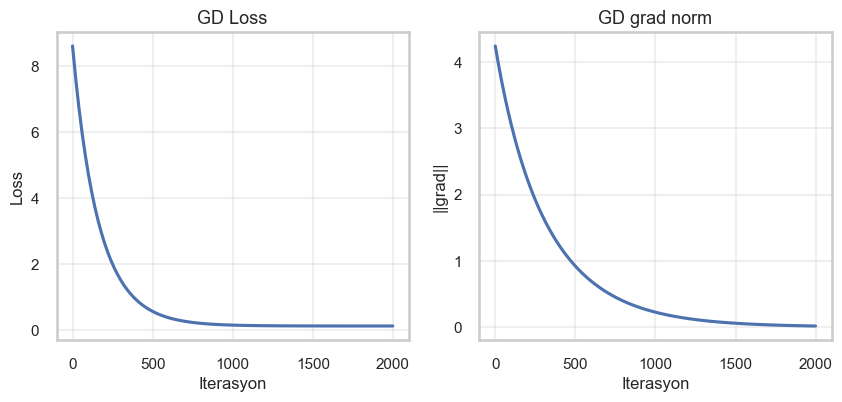

In [96]:
X_tr_std, X_val_std, mean, std = standardize(X_tr, X_val)
theta_gd, hist = gradient_descent(X_tr_std, y_tr, alpha=GD_ALPHA, max_iter=2000, tol=1e-6, log_every=20)
plot_gd_history(hist, path=os.path.join(OUTPUT_DIR, "gd_history.png"))
print("RMSE (GD)", rmse(y_val, predict(X_val_std, theta_gd)))

## 4) Koşullanma deneyi (p taraması 0–12)

In [97]:
p_values = list(range(0, 13))
df_cond = run_conditioning_experiment(
    p_values=p_values, n=2000, d=20, noise_std=0.5,
    alpha=GD_ALPHA, max_iter=2000, tol=1e-6, seed=SEED
)
df_cond.head()

df_cond.to_csv(os.path.join(TABLE_DIR, "conditioning_table.csv"), index=False)


(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Stabil yöntemler'}, xlabel='p (kolinear şiddeti)', ylabel='RMSE (val)'>,
        <Axes: title={'center': 'inverse (outlier)'}, xlabel='p', ylabel='RMSE (val)'>],
       dtype=object))

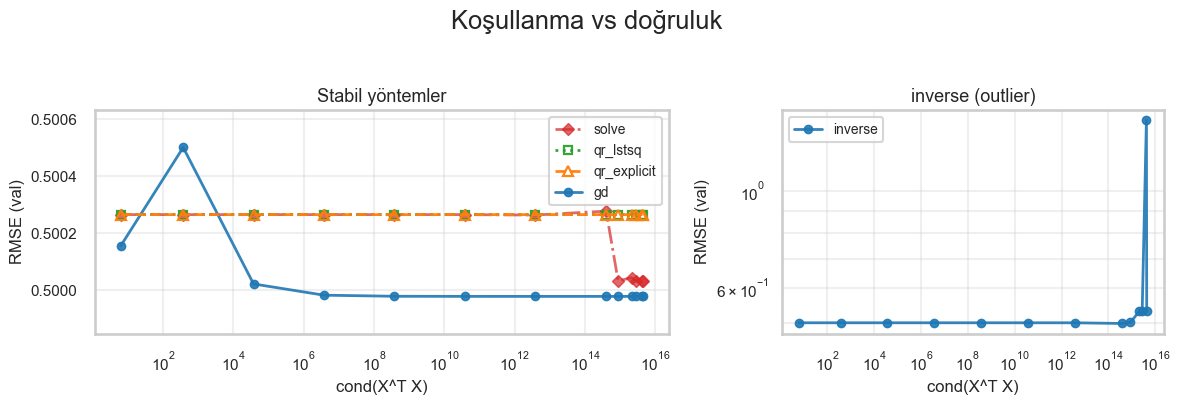

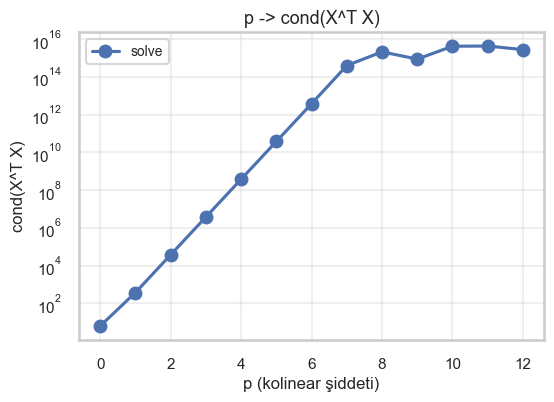

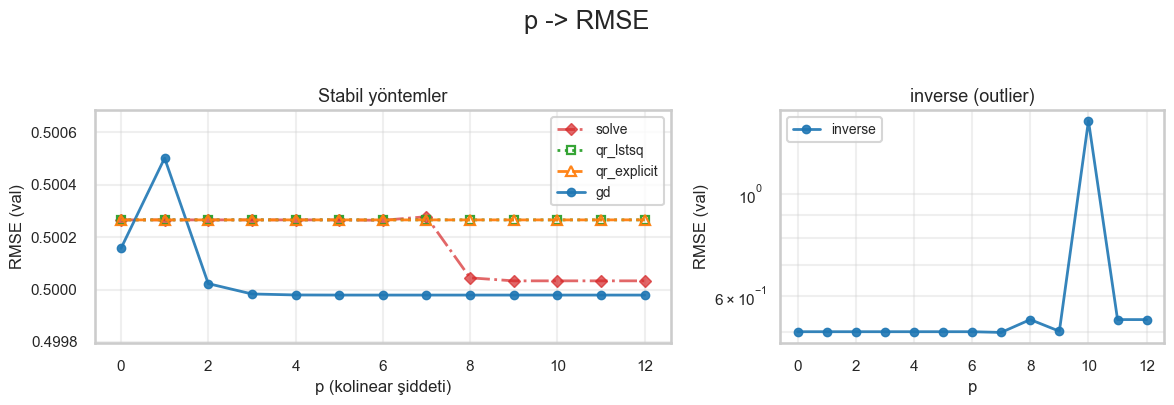

In [98]:
plot_cond_vs_error(df_cond, path=os.path.join(OUTPUT_DIR, "cond_vs_rmse.png"))
plot_p_vs_cond(df_cond[df_cond["method"] == "solve"], path=os.path.join(OUTPUT_DIR, "p_vs_cond.png"))
plot_p_vs_rmse(df_cond, path=os.path.join(OUTPUT_DIR, "p_vs_rmse.png"))

## 5) Gradient checking — epsilon taraması (float64 vs float32)

In [99]:
eps_list = [10.0 ** (-k) for k in range(1, 11)]
df_eps = run_gradient_check_experiment(
    n=500, d=10, p=4, noise_std=0.5, eps_list=eps_list, seed=SEED, include_float32=True
)
df_eps

df_eps.to_csv(os.path.join(TABLE_DIR, "epsilon_sweep.csv"), index=False)


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Gradient checking: epsilon taraması'}, xlabel='epsilon', ylabel='relative error'>)

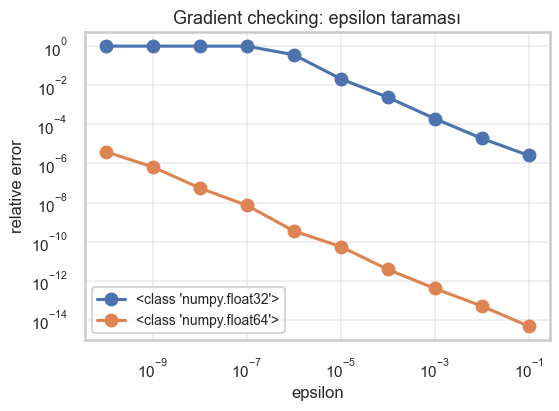

In [100]:
plot_epsilon_sweep(df_eps, path=os.path.join(OUTPUT_DIR, "epsilon_sweep.png"))

In [101]:

# Deney parametreleri meta kaydı
meta = {
    "seed": SEED,
    "p_values": list(range(0, 13)),
    "n_values": [1000, 5000, 10000, 20000, 50000],
    "d_values": [10, 50, 100, 200, 500],
    "gd_params": {"alpha": GD_ALPHA, "max_iter": 5000, "tol": 1e-6},
    "alpha_list": alpha_list,
}
import json
with open(os.path.join(TABLE_DIR, "experiment_meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print("Saved meta ->", os.path.join(TABLE_DIR, "experiment_meta.json"))


Saved meta -> /Users/semihbekdas/Documents/ders notlarim/Numeric/numerikproje/projesemih/outputs/tables/experiment_meta.json


## 6) Runtime ölçekleme

       n  runtime_s method
0   1000   0.000075  solve
1   1000   0.008215     gd
2   5000   0.000109  solve
3   5000   0.045438     gd
4  10000   0.000171  solve
5  10000   0.083520     gd
6  20000   0.000537  solve
7  20000   0.177281     gd
8  50000   0.000997  solve
9  50000   0.467510     gd
     d  runtime_s method
0   10   0.000059  solve
1   10   0.009262     gd
2   50   0.000133  solve
3   50   0.021467     gd
4  100   0.000251  solve
5  100   0.025910     gd
6  200   0.000723  solve
7  200   0.035460     gd
8  500   0.004366  solve
9  500   0.063944     gd


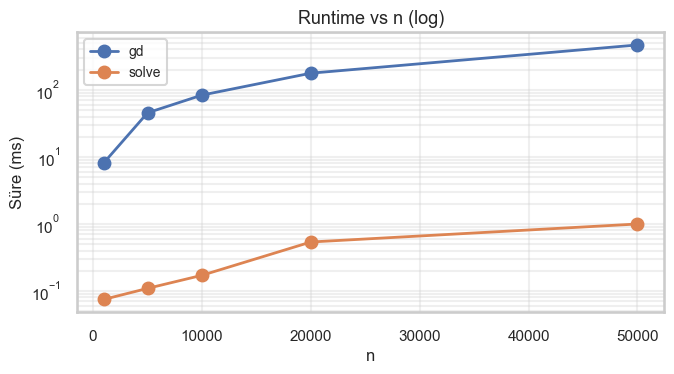

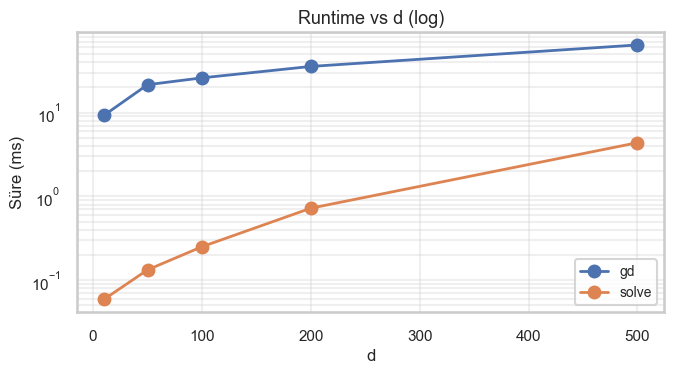

In [102]:
df_n, df_d = run_runtime_experiment(
    n_values=[1000, 5000, 10000, 20000, 50000], d_values=[10, 50, 100, 200, 500], noise_std=0.5, seed=SEED, alpha=GD_ALPHA, max_iter=500, tol=1e-6
)
print(df_n)
print(df_d)
plot_runtime(df_n, "n", "Runtime vs n", path=os.path.join(OUTPUT_DIR, "runtime_n.png"))
plot_runtime(df_d, "d", "Runtime vs d", path=os.path.join(OUTPUT_DIR, "runtime_d.png"))

df_n.to_csv(os.path.join(TABLE_DIR, "runtime_n.csv"), index=False)

df_d.to_csv(os.path.join(TABLE_DIR, "runtime_d.csv"), index=False)


## 7) Gerçek veri deneyi (California Housing / Diabetes fallback)

In [103]:
# Not: California Housing verisi indirilemezse (internet/izin), Diabetes veri setine otomatik düşer.
try:
    from sklearn.datasets import fetch_california_housing, load_diabetes
except Exception as e:
    raise ImportError("scikit-learn import edilemedi. Üstteki pip install hücresini çalıştırın.") from e


def load_real_regression_dataset(val_ratio=0.2, seed=SEED):
    try:
        ds = fetch_california_housing()
        X_raw, y = ds.data, ds.target
        feature_names = list(ds.feature_names)
        dataset_name = "California Housing"
    except Exception as e:
        print("California Housing indirilemedi, Diabetes fallback:", e)
        ds = load_diabetes()
        X_raw, y = ds.data, ds.target
        feature_names = list(getattr(ds, "feature_names", [f"x{i}" for i in range(X_raw.shape[1])]))
        dataset_name = "Diabetes (fallback)"

    # Bias sütunu ekle
    X = np.hstack([np.ones((X_raw.shape[0], 1)), X_raw])

    # Split
    X_tr_raw, X_val_raw, y_tr, y_val = train_val_split(X, y, val_ratio=val_ratio, seed=seed)

    # Koşul sayısı (ham)
    cond_raw = cond_xtx(X_tr_raw)

    # Standardize (bias korunur) — solve/QR/GD hepsi aynı uzayda kıyaslanacak
    X_tr, X_val, mean, std = standardize(X_tr_raw, X_val_raw)
    cond_std = cond_xtx(X_tr)

    return dataset_name, feature_names, X_tr_raw, X_val_raw, X_tr, X_val, y_tr, y_val, cond_raw, cond_std


dataset_name, feature_names, X_tr_raw, X_val_raw, X_tr, X_val, y_tr, y_val, cond_raw, cond_std = load_real_regression_dataset(
    val_ratio=0.2, seed=SEED
)

print("Dataset:", dataset_name)
print("n_train, d (bias dahil):", X_tr.shape)
print("cond(X^T X) raw:", cond_raw)

alpha_list_real = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
df_alpha_real = alpha_sweep_gd_from_data(
    X_tr, X_val, y_tr, y_val,
    alpha_list=alpha_list_real,
    max_iter=1000,
    tol=1e-6,
    log_every=50,
)
df_alpha_real = df_alpha_real.sort_values("rmse_val")
save_table(df_alpha_real, "realdata_alpha_sweep")

best_real = df_alpha_real[df_alpha_real["diverged"] == False].iloc[0]
GD_ALPHA_REAL = float(best_real["alpha"])
print("Selected GD_ALPHA_REAL:", GD_ALPHA_REAL)

rows = []

# solve
start = time.time(); theta_s = normal_eq_solve(X_tr, y_tr); rt = time.time() - start
rows.append({
    "method": "solve",
    "rmse_train": rmse(y_tr, predict(X_tr, theta_s)),
    "rmse_val": rmse(y_val, predict(X_val, theta_s)),
    "runtime_s": rt,
})

# QR (lstsq)
start = time.time(); theta_q = least_squares_qr(X_tr, y_tr); rt = time.time() - start
rows.append({
    "method": "qr_lstsq",
    "rmse_train": rmse(y_tr, predict(X_tr, theta_q)),
    "rmse_val": rmse(y_val, predict(X_val, theta_q)),
    "runtime_s": rt,
})

# QR (explicit)
start = time.time(); theta_qe = least_squares_explicit_qr(X_tr, y_tr); rt = time.time() - start
rows.append({
    "method": "qr_explicit",
    "rmse_train": rmse(y_tr, predict(X_tr, theta_qe)),
    "rmse_val": rmse(y_val, predict(X_val, theta_qe)),
    "runtime_s": rt,
})

# GD
start = time.time()
theta_gd_real, hist_real = gradient_descent(X_tr, y_tr, alpha=GD_ALPHA_REAL, max_iter=5000, tol=1e-6, log_every=50)
rt = time.time() - start
rows.append({
    "method": "gd",
    "rmse_train": rmse(y_tr, predict(X_tr, theta_gd_real)),
    "rmse_val": rmse(y_val, predict(X_val, theta_gd_real)),
    "runtime_s": rt,
    "gd_iters": hist_real["iter"][-1] if hist_real["iter"] else 0,
    "gd_alpha": GD_ALPHA_REAL,
})

real_df = pd.DataFrame(rows)
real_df

Dataset: California Housing
n_train, d (bias dahil): (16512, 9)
cond(X^T X) raw: 57584281826.656906
Saved table -> /Users/semihbekdas/Documents/ders notlarim/Numeric/numerikproje/projesemih/outputs/tables/realdata_alpha_sweep.csv
Selected GD_ALPHA_REAL: 0.01


,method,rmse_train,rmse_val,runtime_s,gd_iters,gd_alpha
0,solve,0.724133,0.724508,0.000183,NaN,NaN
1,qr_lstsq,0.724133,0.724508,0.002109,NaN,NaN
2,qr_explicit,0.724133,0.724508,0.003707,NaN,NaN
3,gd,0.724263,0.723957,0.997397,4999.0,0.01


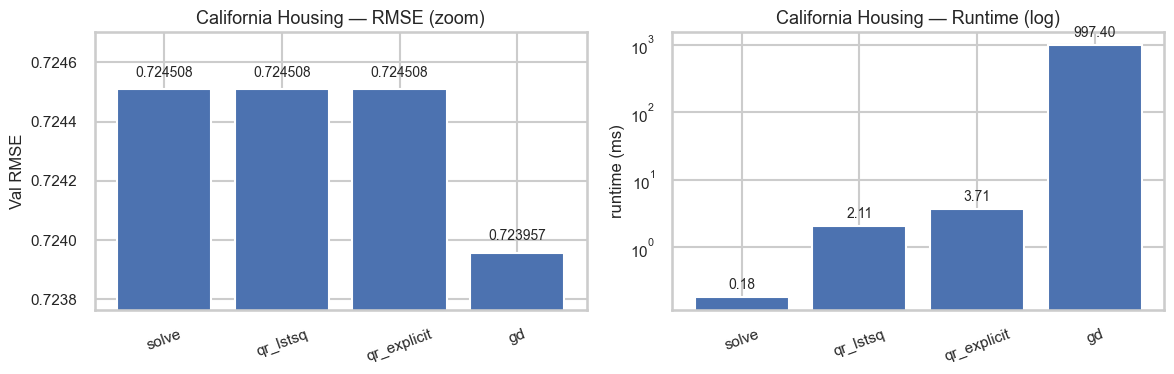

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'GD Loss'}, xlabel='Iterasyon', ylabel='Loss'>,
        <Axes: title={'center': 'GD grad norm'}, xlabel='Iterasyon', ylabel='||grad||'>],
       dtype=object))

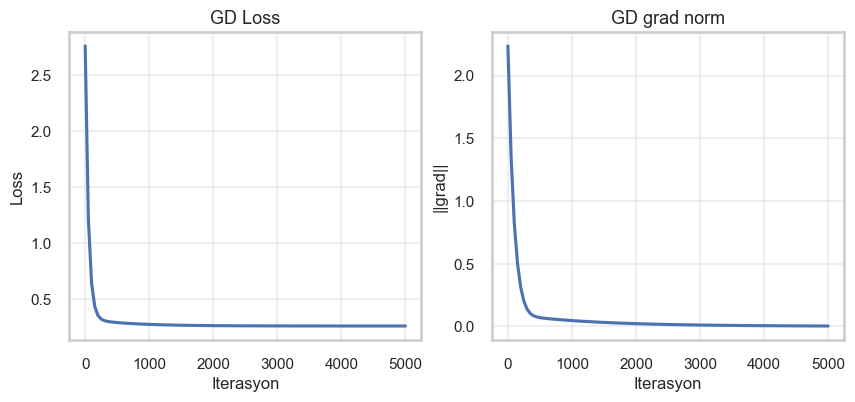

In [104]:
real_df.to_csv(os.path.join(TABLE_DIR, "realdata_metrics.csv"), index=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

rmse_vals = real_df["rmse_val"].astype(float).to_numpy()
bars0 = ax[0].bar(real_df["method"], rmse_vals)
ax[0].set_ylabel("Val RMSE")
ax[0].set_title(f"{dataset_name} — RMSE (zoom)")
ax[0].tick_params(axis='x', rotation=20)
annotate_bars(ax[0], bars0, rmse_vals, fmt="{:.6f}")

if np.isfinite(rmse_vals).any():
    y0 = float(np.nanmin(rmse_vals))
    y1 = float(np.nanmax(rmse_vals))
    pad = (y1 - y0) * 0.35 if y1 > y0 else max(abs(y1) * 0.02, 0.01)
    ax[0].set_ylim(y0 - pad, y1 + pad)

rt_ms = (real_df["runtime_s"].astype(float) * 1000.0).to_numpy()
bars1 = ax[1].bar(real_df["method"], rt_ms)
ax[1].set_ylabel("runtime (ms)")
ax[1].set_title(f"{dataset_name} — Runtime")
ax[1].tick_params(axis='x', rotation=20)

use_log = bool(np.all(np.isfinite(rt_ms)) and np.all(rt_ms > 0))
if use_log:
    ax[1].set_yscale("log")
    ax[1].set_title(f"{dataset_name} — Runtime (log)")

annotate_bars(ax[1], bars1, rt_ms, fmt="{:.2f}", log_scale=use_log)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "realdata_metrics.png"), dpi=150, bbox_inches="tight")
plt.show()

plot_gd_history(hist_real, path=os.path.join(OUTPUT_DIR, "realdata_gd_history.png"))

## 8) Özet (rapora kopyalanabilir)

In [105]:
# Özet (sentetik baz senaryo ile yeniden hesaplanır)
X_sum, y_sum, _ = make_synthetic_linear(n=2000, d=20, p=6, noise_std=0.5, seed=SEED)
X_tr_sum, X_val_sum, y_tr_sum, y_val_sum = train_val_split(X_sum, y_sum, val_ratio=0.2, seed=SEED)

# Kapalı form (solve)
theta_s_sum = normal_eq_solve(X_tr_sum, y_tr_sum)

# GD (standardize)
X_tr_sum_std, X_val_sum_std, mean_sum, std_sum = standardize(X_tr_sum, X_val_sum)
theta_gd_sum, hist_sum = gradient_descent(X_tr_sum_std, y_tr_sum, alpha=GD_ALPHA, max_iter=2000, tol=1e-6, log_every=20)

summary = {
    "cond_example": cond_xtx(X_tr_sum),
    "rmse_solve": rmse(y_val_sum, predict(X_val_sum, theta_s_sum)),
    "rmse_gd": rmse(y_val_sum, predict(X_val_sum_std, theta_gd_sum)),
    "gd_iters": hist_sum["iter"][-1] if hist_sum["iter"] else 0,
    "gd_alpha": GD_ALPHA,
}
summary

summary_df = pd.DataFrame([summary])
save_table(summary_df, 'summary_metrics')

Saved table -> /Users/semihbekdas/Documents/ders notlarim/Numeric/numerikproje/projesemih/outputs/tables/summary_metrics.csv


## 9) Basit Testler

In [106]:
run_tests()

Tests passed.


In [107]:
print("OUTPUT_DIR =", OUTPUT_DIR)
print("TABLE_DIR  =", TABLE_DIR)

OUTPUT_DIR = /Users/semihbekdas/Documents/ders notlarim/Numeric/numerikproje/projesemih/outputs/figures
TABLE_DIR  = /Users/semihbekdas/Documents/ders notlarim/Numeric/numerikproje/projesemih/outputs/tables
